# Notebook A: Candelkeep MVP - Prototype

In this notebook you test whether **Candlekeep’s** routing prototype is strong enough to move forward.

Candlekeep handles **20,000+ customer messages per month**, with roughly **60 hours of manual processing per week** and an average **4.2-hour first response time**. If routing can be automated **safely** and **affordably**, the team can reduce manual effort and speed up handling.

Your job is **not** to prove perfection. Your job is to decide whether this setup is good enough to **continue**, **improve and re-test**, or **stop** — using evidence from a fixed offline evaluation set.

## What this notebook evaluates

1. **Routing quality** — Does the model route to the right department often enough to be useful?
2. **Safety** — If we only automate the safest-looking cases, how risky is that?
3. **Cost** — Is estimated cost acceptable at Candlekeep scale?
4. **Speed** — Is the system fast enough to support a better workflow?

You will **compare** a few candidate models on a sample, **choose** one to study further, then **run a full evaluation** on that model.

## Environment

- **Colab / remote:** uncomment the GitHub install line below (and restart the runtime if prompted).
- **Local (repo):** uncomment the editable install from the repo root, or ensure `src/` is on `PYTHONPATH`.

Keep your API key in **Secrets** (Colab) or a local **`.env`** file — avoid committing real keys.

In [1]:
# Colab / remote
# %pip install -q git+https://github.com/mnrozhkov/ai-leader.git

# Local dev (run from repo root)
%pip install -q -e .
# pass

/Users/mnrozhkov/dev/ai-leader/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


## Step 1 — Configure the experiment

Set your API key and the main settings. You can change **candidate models**, **temperature**, **`MONTHLY_MESSAGES`** (for cost projection), and **`SYSTEM_PROMPT`** (default is the course routing baseline).

For model comparison we use **30%** of the rows (`random_state=42`) so runs stay tractable; the **full dataset** is used in Step 4.

In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
import sys
from pathlib import Path

from dotenv import load_dotenv

_cwd = Path.cwd().resolve()
ROOT = _cwd if (_cwd / "src" / "ai_leader").is_dir() else _cwd.parent
if (ROOT / "src" / "ai_leader").is_dir() and str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from ai_leader import (  # noqa: E402
    DEFAULT_SYSTEM_PROMPT,
    Thresholds,
    build_model_comparison_dataframe,
    compute_safety_metrics,
    create_client,
    evaluate_decision,
    evaluate_model_on_dataframe_async,
    load_and_validate_dataset,
    run_model_comparison_async,
    select_best_model,
)
from ai_leader.reporting import (  # noqa: E402
    display_cost_breakdown,
    display_cost_metrics,
    display_cost_projection,
    display_latency_metrics,
    display_mvp_decision,
    display_quality_metrics,
    display_safety_metrics,
    plot_quality_vs_cost,
    plot_safety_comparison,
    show_figure,
)

load_dotenv(ROOT / ".env" if (ROOT / ".env").is_file() else ".env", override=False)

True

## Settings

In [13]:
# Colab: paste a key here OR use os.environ / a Secret
api_key = os.getenv("TOKENFACTORY_API_KEY") or os.getenv("OPENAI_API_KEY") or ""
if not api_key:
    api_key = input("Paste TokenFactory API key (or set env): ").strip()

DATASET_URL = os.getenv(
    "AI_LEADER_DATASET_PATH",
    "https://docs.google.com/spreadsheets/d/e/2PACX-1vSU5zvx8wgk9FMEcRGlCtXkE4_T90OgsrqU4QPNZC478Rsp5JEBEEUjvlMkY3iMoiAmpa1zQ5QFkgT5/pub?output=csv",
)

TEMPERATURE = 0.1
MONTHLY_MESSAGES = 20_000

DECISION_THRESHOLDS = Thresholds(
    department_accuracy_pass=0.85,
    category_accuracy_pass=0.85,
    unsafe_auto_route_rate_pass=0.03,
    monthly_cost_usd_pass=1_000.0,
    p95_latency_ms_pass=5_000.0,
)
display(DECISION_THRESHOLDS)

## Step 2 — Load the evaluation dataset

The CSV holds labeled customer requests with gold routing targets. We use it to measure how the routing prototype performs beyond a handful of ad-hoc examples.

In [4]:
df = load_and_validate_dataset(DATASET_URL)
print(f"Rows loaded: {len(df)}")
df.head(3)

Rows loaded: 100


,Request Text,Submission Channel,Related to order,Order ID,Category,Routing to Department,Timestamp,Order History,row_id
0,My Autumn Oak table arrived with a cracked leg...,Email,True,CK-8821,Order Issue,Returns,2025-10-01 09:12:00,2025-09-24 — Order placed | 2025-09-25 — Shipp...,0
1,I need to change my address for order CK-9902....,Chat,True,CK-9902,Delivery,Logistics,2025-09-19 14:00:00,2025-09-12 — Order placed | 2025-09-14 — Shipp...,1
2,Where is my package? The tracking says DPD has...,Social,True,CK-1102,Delivery,Logistics,2025-10-01 10:15:00,2025-09-24 — Order placed | 2025-09-26 — Shipp...,2


**Optional:** inspect how departments are distributed in the gold labels.

In [5]:
df["Routing to Department"].value_counts()

Routing to Department
Logistics           29
Customer Support    27
Product Team        23
Returns             21
Name: count, dtype: int64

## Step 3 — Compare candidate models

On a **random sample** of the dataset, run all candidates and build a comparison table.

The table and charts use the **same column set** as `scripts/run_notebook_a.py` (`comparison_table.csv`) when `show_all=True`, including safety metrics, so **quality vs cost** and **safety bars** match that tool. Numbers still differ if the CLI run uses the full sheet or a different fixture while this step uses the 30% sample.

### Metric primer (used in Notebook A and B)

- **`department_accuracy`**  
  Meaning: share of rows with correct routed department.  
  Formula: `(# rows where predicted department == gold department) / total_rows`.  
  Interpretation: higher is better; this is the main routing KPI.

- **`category_accuracy`**  
  Meaning: share of rows with correct category label.  
  Formula: `(# rows where predicted category == gold category) / total_rows`.  
  Interpretation: higher is better; useful secondary signal, but less critical than department routing.

- **`unsafe_auto_route_rate`**  
  Meaning: among rows the policy would auto-route, how many are wrong routes.  
  Formula: `(# wrong routes inside auto-routed subset) / (# auto-routed rows)`.  
  Interpretation: lower is better; this is the key safety guardrail for automation.

- **`monthly_cost_usd`**  
  Meaning: projected monthly inference spend at configured volume.  
  Formula: `cost_per_message_usd * MONTHLY_MESSAGES`.  
  Interpretation: lower is better, but evaluate together with quality/safety (cheap but wrong is not acceptable).

- **`p95_latency_ms`**  
  Meaning: 95th percentile model latency in milliseconds.  
  Formula: sort per-row latencies; take the value at the 95th percentile.  
  Interpretation: lower is better; captures tail latency (worst-case user experience) better than median alone.

**Suggested model:** lowest **misroute rate**. Tie-breakers: **higher** department accuracy, then **lower** cost per message, then **lower** median latency.

The notebook can suggest a model automatically; you may **override** `MODEL_TO_EVALUATE` if you have a clear reason.



In [6]:
print(DEFAULT_SYSTEM_PROMPT)

You are a support routing assistant.
Return a JSON object with:
- Category
- Routing to Department
- [Agent] Initial Response
- Confidence (High, Medium, Low)
Follow the schema exactly and do not add extra keys.


In [7]:
CANDIDATE_MODELS = [
    "deepseek-ai/DeepSeek-V3.2",
    "zai-org/GLM-5",
    "openai/gpt-oss-120b",
]

model_runs = await run_model_comparison_async(
    df=df.sample(frac=0.3, random_state=42),
    models=CANDIDATE_MODELS,
    api_key=api_key,
    system_prompt=DEFAULT_SYSTEM_PROMPT,
    temperature=0.1,
    monthly_messages=20000,
    use_progress=True,
)

Output()

Output()

Output()

In [8]:
comparison_df = build_model_comparison_dataframe(df, model_runs, show_all=True)
comparison_df

,model,department_accuracy,misroute_rate,category_accuracy,cost_per_message_usd,monthly_cost_usd,cost_source,median_latency_ms,p95_latency_ms,latency_source,auto_route_coverage,auto_route_precision,unsafe_auto_route_rate,manual_review_rate
0,deepseek-ai/DeepSeek-V3.2,0.333,0.667,0.567,0.000,1.400,measured,3151.217,4323.576,measured,0.967,0.310,0.667,0.033
1,zai-org/GLM-5,0.533,0.467,0.500,0.002,41.517,measured,15717.264,24802.134,measured,1.000,0.533,0.467,0.000
2,openai/gpt-oss-120b,0.567,0.433,0.567,0.000,3.309,measured,2122.190,3828.932,measured,1.000,0.567,0.433,0.000


**Optional charts:** quality vs cost (and safety bar chart when there are 2+ models). Figures use `show_figure` so they render once in `inline` backends.

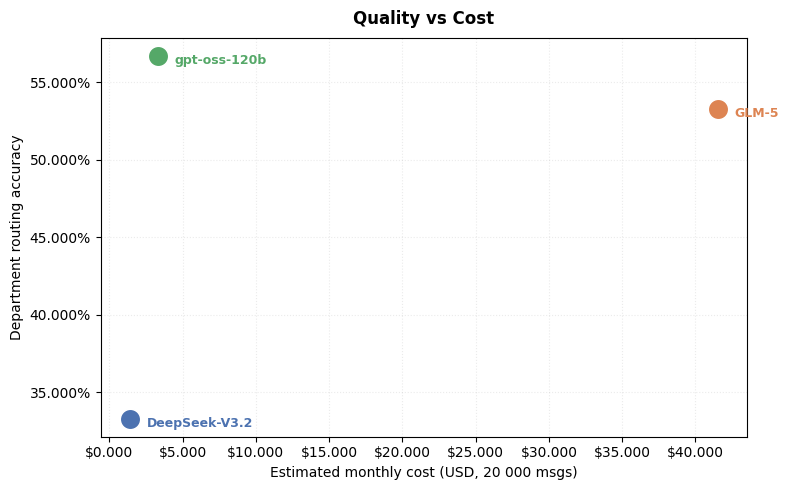

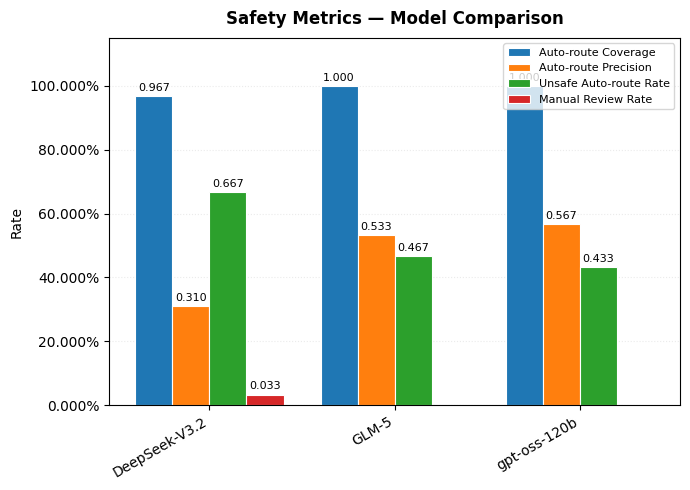

In [9]:
if not comparison_df.empty:
    show_figure(plot_quality_vs_cost(comparison_df))
    show_figure(plot_safety_comparison(comparison_df))

## Step 4 — Run full evaluation on the selected model

Now score **every row** in `df` for the model you chose. This produces the predictions used for the MVP-style decision below.

Because Step 3 already used `await`, Jupyter has an active event loop — use **`await evaluate_model_on_dataframe_async`** here (the sync `evaluate_model_on_dataframe` wraps `asyncio.run`, which conflicts with that).

In [10]:
# Select a model for evaluation

BEST_MODEL = select_best_model(model_runs)
print("Suggested model:", BEST_MODEL)

Suggested model: openai/gpt-oss-120b


In [11]:
# Configure system prompt

SYSTEM_PROMPT = """
You are a support routing assistant.
Return a JSxON object with:
- Category
- Routing to Department
- [Agent] Initial Response
- Confidence (High, Medium, Low)
Follow the schema exactly and do not add extra keys.
"""

In [12]:
client = create_client(api_key, model=BEST_MODEL)

selected_run = await evaluate_model_on_dataframe_async(
    df=df,
    model=BEST_MODEL,
    client=client,
    system_prompt=SYSTEM_PROMPT,
    temperature=0.1,
    monthly_messages=MONTHLY_MESSAGES,
    use_progress=True,
)

NameError: name 'MONTHLY_MESSAGES' is not defined

## Step 5 — Check routing quality

Focus on **misroute rate** (primary), **department accuracy**, and **category accuracy** (diagnostic).

A useful working target for Candlekeep is roughly **≤ 10% misroutes** if routing is to be considered strong enough for the next step (aligns with routing / escalation goals — still interpret in context).

In [ ]:
display_quality_metrics(quality_metrics=selected_run.quality_metrics)

,Misroute rate,Department accuracy,Category accuracy,Rows evaluated
0,0.39,0.61,0.62,100.0


## Step 6 — Check safety under a simple review rule

**Policy:** **High** confidence → candidate for auto-route; **everything else** → human review.

Ask: what share could be automated now, how risky is that slice, and is confidence useful for selective automation?

In [ ]:
sm = compute_safety_metrics(df, selected_run.predictions)
display_safety_metrics(safety_metrics=sm)

,Auto-route coverage,Auto-route precision,Unsafe auto-route rate,Manual review rate
0,0.94,0.628,0.35,0.06


## Step 7 — Check cost at Candlekeep scale

Manual handling and slow responses already carry cost; **cost per message** and **monthly** projection matter for the MVP decision. Note whether figures are **measured** from usage or **estimated** from the price sheet.

Below we break this into transparent steps: assumptions, per-message token economics, and monthly/annual projection.

In [ ]:
display_cost_metrics(cost_metrics=selected_run.cost_metrics)

,Cost per message (USD),Monthly cost (USD),Annual cost (USD),Cost source
0,0.0,3.901,46.807,measured


### Step 7A — Cost assumptions and per-message token economics

This makes each input explicit before projecting monthly and annual totals.

In [ ]:
display_cost_breakdown(
    model=BEST_MODEL,
    cost_metrics=selected_run.cost_metrics,
    monthly_messages=MONTHLY_MESSAGES,
)

,Assumption,Value
0,Model,openai/gpt-oss-120b
1,Messages per month,20000
2,Avg input tokens per message,257.0
3,Avg output tokens per message,382.54
4,Input price (USD / 1M tokens),0.15
5,Output price (USD / 1M tokens),0.6
6,Cost source,measured


,Token type,Avg tokens / message,Price (USD / 1M tokens),Cost / message (USD)
0,Input,257.00,0.15,0.000039
1,Output,382.54,0.60,0.000230
2,Total,639.54,NaN,0.000268


In [ ]:
display_cost_projection(
    cost_metrics=selected_run.cost_metrics,
    monthly_messages=MONTHLY_MESSAGES,
)


**Formulas used**

- `input_cost_per_message = avg_input_tokens_per_message * input_price_per_1M / 1_000_000`
- `output_cost_per_message = avg_output_tokens_per_message * output_price_per_1M / 1_000_000`
- `cost_per_message = input_cost_per_message + output_cost_per_message`
- `monthly_cost = cost_per_message * monthly_messages`
- `annual_cost = monthly_cost * 12`


,Metric,Value
0,Messages per month,20000.000000
1,Cost per message (USD),0.000268
2,Monthly cost (USD),5.361480
3,Annual cost (USD),64.337760


At 20,000 messages/month, projected cost is $5.36/month (~$64.34/year).


## Step 8 — Check speed feasibility

This checks whether calls are **technically** fast enough for a better process (not full end-to-end workflow proof). Candlekeep’s broader goal is moving from a **4.2-hour** first response toward **faster** acknowledgment.

If `median_latency_ms` is missing, latency was not measured in this run.

In [ ]:
display_latency_metrics(latency_metrics=selected_run.latency_metrics)

,Median latency (ms),p95 latency (ms),Latency source
0,2250.531,3901.206,measured


## Step 9 — Review the full evaluation summary

Combine quality, safety, cost, and speed into a single MVP-style summary: **`display_mvp_decision`** shows a table (status + thresholds per dimension) and the text recommendation — easier to read than raw JSON.

In [ ]:
decision = evaluate_decision(
    quality_metrics=selected_run.quality_metrics,
    safety_metrics=sm,
    cost_metrics=selected_run.cost_metrics,
    latency_metrics=selected_run.latency_metrics,
    thresholds=DECISION_THRESHOLDS,
)
display_mvp_decision(decision=decision)

,Dimension,Status,Value,Pass threshold (≤),Borderline threshold (≤)
0,Routing Quality,fail,0.610,0.10,0.15
1,Safety,fail,0.350,0.03,0.06
2,Cost,pass,0.000,0.05,0.10
3,Speed,pass,4131.102,5000.00,10000.00


**Recommendation:** `Improve and re-test (failing: routing_quality, safety)`

## Summary

Notebook A is a **baseline validation** step, not the final optimization endpoint. The baseline prompt is intentionally simple, and even small prompt improvements often shift routing quality and safety metrics.

Because of that, recommendations should be based on the **latest evidence** and interpreted as a checkpoint: if baseline is weak or borderline, the correct next move is usually **Improve and re-test** rather than a hard stop.

To systematically improve outcomes, follow the Notebook B pattern:
- strengthen routing instructions and output constraints,
- compare baseline vs improved prompt on the same evaluation slice,
- test few-shot and related techniques where helpful,
- reassess quality, safety, cost, and latency trade-offs before final go/no-go decisions.

In short: use Notebook A to establish a reliable starting point, then use Notebook B to drive meaningful quality gains with structured iteration.